<a href="https://colab.research.google.com/github/Numpaque4/pryngles-numpaque/blob/kiss/doc/tests/kepler_51_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Installing `Pryngles`**

In [ ]:
!pip install -q git+https://github.com/Numpaque4/pryngles-numpaque

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import pryngles as pr

#**External Packages**

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

%matplotlib inline

#**Model #1**

In [ ]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #Mstar
Rp = 1.598212e-02*Rs #Rstar

#Ring Parameters
opacity = 1
i_ring = 74.6*pr.DEG #Deg
roll = 56.9*pr.DEG #Deg
fi, fe = 1, 6.452317 #Rplanet

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = 89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0.296, 0.4] #https://arxiv.org/html/2410.01625v2#abstract

In [ ]:
system = pr.System()

star = system.add(kind = "Star",
                  radius = Rs/system.ul,
                  m = Ms/system.um,
                  limb_coeffs = limb_cf)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = 0, m = 0,
                    radius = Rp/system.ul)

ring = system.add(kind = "Ring", parent = planet,
                  fi = fi, fe = fe,
                  i = i_ring, roll = -roll)

In [ ]:
# Setting Observer to the Ecplitic Plane
system.n_obs = pr.Science.direction(0, 90 - inc*pr.RAD)

# Configurating the System
system.initialize_simulation()
system.spangle_system()

(-9.63201287425033e-10, -0.0002944520828809958)

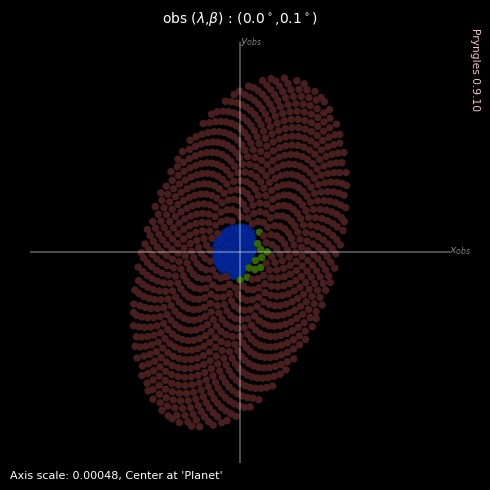

In [ ]:
system.sg.plot2d(include = ['Planet', 'Ring'])

In [ ]:
#Initialize Optical Depth Values
taur_values = {name: np.inf
               for name in system.bodies}

system.data.tau_gray_optical = system.data.name.map(taur_values)

##**Transit Light Curve**

In [ ]:
#Contact-Edge Time
t_lim = np.arctan((star.radius + planet.radius)/planet.a)/(2*np.pi/system.sim.orbit.Ps[0])

#Times of Integration
Nts = 100
ts_transit = np.linspace(-1.5*t_lim, 1.5*t_lim, Nts)

# Flux Values for Planet and Ring
transit_system = np.zeros((Nts, 2))

# Integrating
for i, t in enumerate(ts_transit):

  # Integration for System
  system.integrate_perspective(t)
  system.update_Transit()

  # Values for every Time-Step
  transit_system[i] = pd.Series(system.data.transit_flux.values,
                                index = system.data.name
                                ).groupby('name').sum()[['Planet', 'Ring']]

In [ ]:
go.Figure([go.Scatter(x = ts_transit*system.ut/pr.Const.hours,
                      y = 1 - transit_system.sum(axis = 1),
                      name = 'Total',
                      showlegend = True)],

          layout = go.Layout(width = 900, height = 600,
                             title_x = 0.5, title_y = 0.95,
                             xaxis_title = 't [h]',
                             yaxis_title = 'Normalized Flux',
                             title_text = 'Planet-Ring Model Light Curve<br>( System )',
                             legend = dict(orientation = 'h',
                                           y = 1.08, x = 0.68)))

##**Diffuse Reflection Light Curve**

In [ ]:
# One Period
ts_reflected = np.linspace(0, system.sim.orbit.Ps[0], Nts)

# Flux Values for Planet and Ring
reflected_system = np.zeros((Nts, 2))

# Integrating
for i, t in enumerate(ts_reflected):

    # Integration for System
    system.integrate_perspective(t)
    system.update_StellarFlux()
    system.update_DiffuseReflection()

    # Values for every Time-Step
    reflected_system[i] = pd.Series(system.data.reflected_flux.values,
                                    index = system.data.name).groupby('name').sum()[['Planet', 'Ring']]

In [ ]:
go.Figure([go.Scatter(x = ts_reflected*system.ut/pr.Const.days,
                      y = reflected_system.sum(axis = 1)*pr.Consts.ppm,
                      name = 'Total',
                      showlegend = True),
           go.Scatter(x = ts_reflected*system.ut/pr.Const.days,
                      y = reflected_system[:,0]*pr.Consts.ppm,
                      name = 'Planet',
                      showlegend = True),
           go.Scatter(x = ts_reflected*system.ut/pr.Const.days,
                      y = reflected_system[:,1]*pr.Consts.ppm,
                      name = 'Ring',
                      showlegend = True)],

          layout = go.Layout(width = 900, height = 600,
                             title_x = 0.5, title_y = 0.95,
                             xaxis_title = 't [h]',
                             yaxis_title = 'Normalized Flux',
                             title_text = 'Planet-Ring Model Light Curve<br>( System )',
                             legend = dict(orientation = 'h',
                                           y = 1.08, x = 0.68)))

##**RingedPlanet Diffuse Reflection (No Correr)**

In [ ]:
RP = pr.RingedPlanet(Nb = 0, Np = 987, Ns = 987, Nr = 1000,
                     Rint = fi, Rext = fe,
                     a = a, e = e, i = i_ring,
                     Rstar = Rs/pr.Consts.au,
                     Rplanet = Rp/pr.Consts.au,
                     Mstar = Ms/pr.Consts.msun,
                     eobs_ecl = [np.pi/2 + roll, np.pi/2 - inc],
                     physics = dict(limb_cs = limb_cf))

In [ ]:
#One Period
lambdas = np.linspace(3*np.pi/2 + roll ,
                       3*np.pi/2 + roll + 2*np.pi, 360)

#Flux Values for Planet
reflected_RP = np.zeros((360, 2))

#Integrating
for i, lam in enumerate(lambdas):

  #Integrating on time domain for RingedPlanet
  RP.changeStellarPosition(lam)

  # Computing DiffuseReflection for RingedPlanet
  RP.updateOpticalFactors()
  RP.updateDiffuseReflection()

  # Values for every Time-Step
  reflected_RP[i] = [RP.Rip.sum(), RP.Rir.sum()]

In [ ]:
go.Figure([go.Scatter(x = ts_reflected*system.ut/pr.Const.days,
                      y = reflected_RP.sum(axis = 1)*pr.Consts.ppm,
                      name = 'Total',
                      showlegend = True),
           go.Scatter(x = ts_reflected*system.ut/pr.Const.days,
                      y = reflected_RP[:,0]*pr.Consts.ppm,
                      name = 'Planet',
                      showlegend = True),
           go.Scatter(x = ts_reflected*system.ut/pr.Const.days,
                      y = reflected_RP[:,1]*pr.Consts.ppm,
                      name = 'Ring',
                      showlegend = True)],

          layout = go.Layout(width = 900, height = 600,
                             title_x = 0.5, title_y = 0.95,
                             xaxis_title = 't [d]',
                             yaxis_title = 'Normalized Flux',
                             title_text = 'Planet-Ring Model Light Curve<br>( RP )',
                             legend = dict(orientation = 'h',
                                           y = 1.08, x = 0.68)))



---

#**Model #2**

In [ ]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #MJup
Rp = 5.963044e-02*Rs #Rstar

#Ring Parameters
opacity = 1
i_ring = 78.3*pr.DEG #Deg
roll = 83*pr.DEG #Deg
fi, fe = 1, 2.369578 #Rplanet

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = 89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0.296, 0.4] #https://arxiv.org/html/2410.01625v2#abstract

In [ ]:
system2 = pr.System()

star2 = system2.add(kind = "Star",
                  radius = Rs/system2.ul,
                  m = Ms/system2.um,
                  limb_coeffs = limb_cf)

planet2 = system2.add(kind = "Planet", parent = star2,
                    a = a, e = 0, m = 0,
                    radius = Rp/system2.ul)

ring2 = system2.add(kind = "Ring", parent = planet2,
                  fi = fi, fe = fe,
                  i = i_ring, roll = -roll)

In [ ]:
# Setting Observer to the Ecplitic Plane
system2.n_obs = pr.Science.direction(0, 90 - inc*pr.RAD)

# Configurating the System
system2.initialize_simulation()
system2.spangle_system()

(-3.5937733278006287e-09, -0.00029484036281055074)

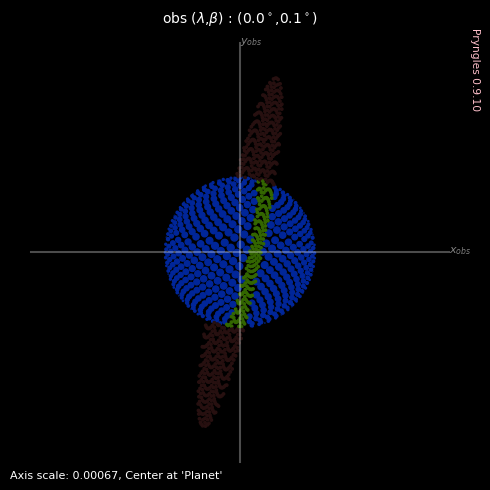

In [ ]:
system2.sg.plot2d(include = ['Planet', 'Ring'])

In [ ]:
#Initialize Optical Depth Values
taur_values = {name: np.inf
               for name in system2.bodies}

system2.data.tau_gray_optical = system2.data.name.map(taur_values)

##**Transit Light Curve**

In [ ]:
#Contact-Edge Time
t_lim = np.arctan((star2.radius + planet2.radius)/planet2.a)/(2*np.pi/system2.sim.orbit.Ps[0])

#Times of Integration
Nts = 100
ts_transit2 = np.linspace(-1.5*t_lim, 1.5*t_lim, Nts)

# Flux Values for Planet and Ring
transit_system2 = np.zeros((Nts, 2))

# Integrating
for i, t in enumerate(ts_transit2):

  # Integration for System
  system2.integrate_perspective(t)
  system2.update_Transit()

  # Values for every Time-Step
  transit_system2[i] = pd.Series(system2.data.transit_flux.values,
                                index = system2.data.name
                                ).groupby('name').sum()[['Planet', 'Ring']]

In [ ]:
go.Figure([go.Scatter(x = ts_transit2*system2.ut/pr.Const.hours,
                      y = 1 - transit_system2.sum(axis = 1),
                      name = 'Total',
                      showlegend = True)],

          layout = go.Layout(width = 900, height = 600,
                             title_x = 0.5, title_y = 0.95,
                             xaxis_title = 't [h]',
                             yaxis_title = 'Normalized Flux',
                             title_text = 'Planet-Ring Model Light Curve<br>( System )',
                             legend = dict(orientation = 'h',
                                           y = 1.08, x = 0.68)))

##**Diffuse Reflection Light Curve**

In [ ]:
# One Period
ts_reflected2 = np.linspace(0, system2.sim.orbit.Ps[0], Nts)

# Flux Values for Planet and Ring
reflected_system2 = np.zeros((Nts, 2))

# Integrating
for i, t in enumerate(ts_reflected2):

    # Integration for System
    system2.integrate_perspective(t)
    system2.update_StellarFlux()
    system2.update_DiffuseReflection()

    # Values for every Time-Step
    reflected_system2[i] = pd.Series(system2.data.reflected_flux.values,
                                    index = system2.data.name).groupby('name').sum()[['Planet', 'Ring']]

In [ ]:
go.Figure([go.Scatter(x = ts_reflected2*system2.ut/pr.Const.days,
                      y = reflected_system2.sum(axis = 1)*pr.Consts.ppm,
                      name = 'Total',
                      showlegend = True),
           go.Scatter(x = ts_reflected2*system2.ut/pr.Const.days,
                      y = reflected_system2[:,0]*pr.Consts.ppm,
                      name = 'Planet',
                      showlegend = True),
           go.Scatter(x = ts_reflected2*system2.ut/pr.Const.days,
                      y = reflected_system2[:,1]*pr.Consts.ppm,
                      name = 'Ring',
                      showlegend = True)],

          layout = go.Layout(width = 900, height = 600,
                             title_x = 0.5, title_y = 0.95,
                             xaxis_title = 't [h]',
                             yaxis_title = 'Normalized Flux',
                             title_text = 'Planet-Ring Model Light Curve<br>( System )',
                             legend = dict(orientation = 'h',
                                           y = 1.08, x = 0.68)))

##**RingedPlanet Diffuse Reflection (No Correr)**

In [ ]:
RP2 = pr.RingedPlanet(Nb = 0, Np = 987, Ns = 987, Nr = 1000,
                     Rint = fi, Rext = fe,
                     a = a, e = e, i = i_ring,
                     Rstar = Rs/pr.Consts.au,
                     Rplanet = Rp/pr.Consts.au,
                     Mstar = Ms/pr.Consts.msun,
                     eobs_ecl = [np.pi/2 + roll, np.pi/2 - inc],
                     physics = dict(limb_cs = limb_cf))

In [ ]:
#One Period
lambdas2 = np.linspace(3*np.pi/2 + roll ,
                       3*np.pi/2 + roll + 2*np.pi, 360)

#Flux Values for Planet
reflected_RP2 = np.zeros((360, 2))

ts_reflected2 = np.zeros(360)

#Integrating
for i, lam in enumerate(lambdas2):

  #Integrating on time domain for RingedPlanet
  RP2.changeStellarPosition(lam)

  # Computing DiffuseReflection for RingedPlanet
  RP2.updateOpticalFactors()
  RP2.updateDiffuseReflection()

  # Values for every Time-Step
  reflected_RP2[i] = [RP2.Rip.sum(), RP2.Rir.sum()]

  ts_reflected2[i] = RP2.t

In [ ]:
go.Figure([go.Scatter(x = ts_reflected2*system2.ut/pr.Const.days,
                      y = reflected_RP2.sum(axis = 1)*pr.Consts.ppm,
                      name = 'Total',
                      showlegend = True),
           go.Scatter(x = ts_reflected2*system2.ut/pr.Const.days,
                      y = reflected_RP2[:,0]*pr.Consts.ppm,
                      name = 'Planet',
                      showlegend = True),
           go.Scatter(x = ts_reflected2*system2.ut/pr.Const.days,
                      y = reflected_RP2[:,1]*pr.Consts.ppm,
                      name = 'Ring',
                      showlegend = True)],

          layout = go.Layout(width = 900, height = 600,
                             title_x = 0.5, title_y = 0.95,
                             xaxis_title = 't [d]',
                             yaxis_title = 'Normalized Flux',
                             title_text = 'Planet-Ring Model Light Curve<br>( RP )',
                             legend = dict(orientation = 'h',
                                           y = 1.08, x = 0.68)))